📥 Loading STURLA grid data...

🌳 STURLA REGRESSION TREE RULES
|--- pct_pave <= 30.77
|   |--- pct_green <= 9.83
|   |   |--- pct_pave <= 25.31
|   |   |   |--- value: [20.81]
|   |   |--- pct_pave >  25.31
|   |   |   |--- value: [22.43]
|   |--- pct_green >  9.83
|   |   |--- pct_pave <= 25.70
|   |   |   |--- value: [18.83]
|   |   |--- pct_pave >  25.70
|   |   |   |--- value: [20.46]
|--- pct_pave >  30.77
|   |--- pct_green <= 8.86
|   |   |--- pct_pave <= 36.08
|   |   |   |--- value: [24.17]
|   |   |--- pct_pave >  36.08
|   |   |   |--- value: [25.52]
|   |--- pct_green >  8.86
|   |   |--- pct_pave <= 35.12
|   |   |   |--- value: [22.00]
|   |   |--- pct_pave >  35.12
|   |   |   |--- value: [23.45]

📸 Tree diagram saved to ./data/sturla_tree_diagram.png


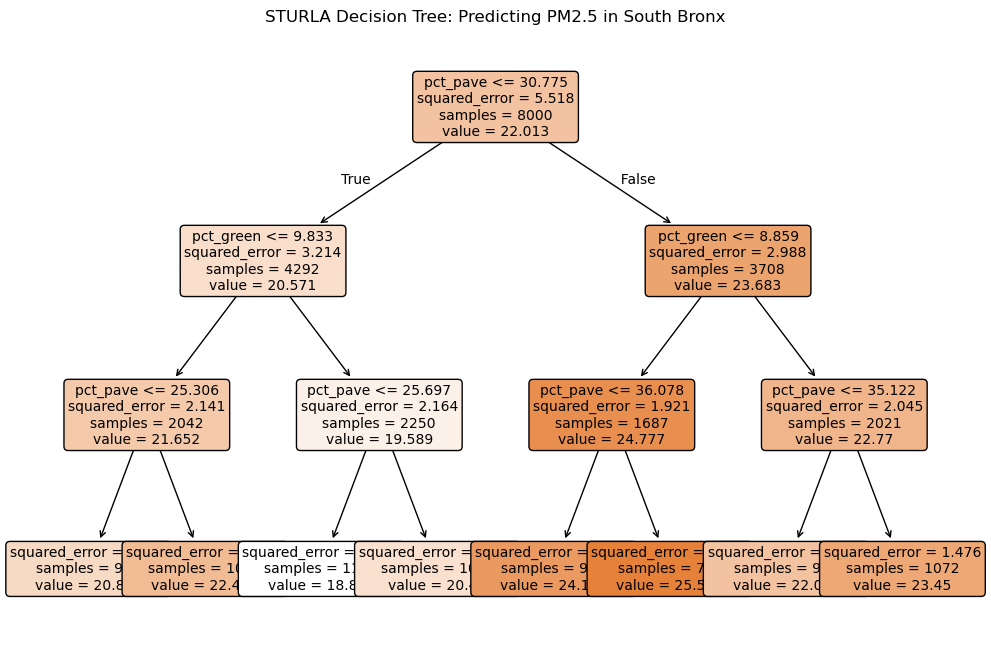

In [1]:
import pandas as pd
import geopandas as gpd
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import tree

# 1. Load the grid we just generated
print("📥 Loading STURLA grid data...")
gdf = gpd.read_file('./data/sturla_grid_with_percentages.geojson')

# 2. Define our Features (X) and our Target (y)
# We want to see how buildings, pavement, and green space predict pollution
features = ['pct_building', 'pct_pave', 'pct_green']
X = gdf[features]
y = gdf['pm25_concentration']

# 3. Split the data to validate the model (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Regression Tree
# We keep max_depth=3 so the tree is simple enough to put on a slide
regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
regressor.fit(X_train, y_train)

# 5. Export the Rules
text_representation = export_text(regressor, feature_names=features)
print("\n" + "="*30)
print("🌳 STURLA REGRESSION TREE RULES")
print("="*30)
print(text_representation)
print("="*30)

# 6. Optional: Save a visual of the tree
plt.figure(figsize=(12,8))
tree.plot_tree(regressor, feature_names=features, filled=True, rounded=True, fontsize=10)
plt.title("STURLA Decision Tree: Predicting PM2.5 in South Bronx")
plt.savefig('./data/sturla_tree_diagram.png')
print("📸 Tree diagram saved to ./data/sturla_tree_diagram.png")